# Paper Figure: Reward Function Ablation

Ablation study over GRPO reward composition. Three conditions:
- **Acc + Faith**: the paper's combined reward `r_base(y) + λ · 𝟙(B_CoT = B_INT)` (main setting)
- **Acc only**: drop the faithfulness term
- **Faith only**: drop the accuracy term

Figure: 3×3 grid (tasks × models). Each panel shows CIA over training steps, with the three reward conditions as separately styled lines.

Paper-quality styling: shared legend, base-model dashed baseline, peak checkpoint markers, collapse region shading, optional secondary y-axis for accuracy.

Data format assumed: `<runs_dir>/<run_name>.csv` with columns `step, cia, accuracy, kl, completion_length` (one row per logging step). Matching run names are built from `TASKS × MODELS × REWARD_VARIANTS` via `build_run_name()`. Missing files render as blank panels with a "(no data)" note.

In [1]:
# ============================================================
# Imports + paper-quality matplotlib style
# ============================================================
import os, json, re, glob
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D

# Paper style — tweak once, inherit everywhere.
mpl.rcParams.update({
    "figure.dpi":         100,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "font.family":        "DejaVu Sans",
    "font.size":          10,
    "axes.labelsize":     11,
    "axes.titlesize":     11,
    "legend.fontsize":    9,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.25,
    "grid.linestyle":     "--",
    "grid.linewidth":     0.6,
    "lines.linewidth":    2.0,
})

In [2]:
# ============================================================
# Configuration: tasks, models, variants, colors, paths
# ============================================================
TASKS  = ["two_hop", "hint", "multiplication"]
TASK_LABELS = {
    "two_hop":        "Two-Hop",
    "hint":           "MMLU-Hint",
    "multiplication": "2-Digit Multiplication",
}

MODELS       = ["llama3_8b", "gemma_9b", "qwen3_8b"]
MODEL_LABELS = {
    "llama3_8b": "Llama-3-8B",
    "gemma_9b":  "Gemma-2-9B",
    "qwen3_8b":  "Qwen3-8B",
}

# Reward variants — the three ablation conditions. Each maps to a
# colour, linestyle, zorder, and a short legend label.
VARIANTS = {
    "acc_faith": dict(label="Acc + Faith (full)",  color="#E67E22", ls="-",  lw=2.5, z=3),
    "acc_only":  dict(label="Acc only",            color="#7F8C8D", ls="--", lw=2.0, z=2),
    "faith_only":dict(label="Faith only",          color="#3498DB", ls=":",  lw=2.0, z=2),
}

# Directory layout. Drop CSVs named <run_name>.csv here.
RUNS_DIR = Path("${REPO_ROOT}/Figures/runs")
RUNS_DIR.mkdir(parents=True, exist_ok=True)
FIG_OUT  = Path("${REPO_ROOT}/Figures/out")
FIG_OUT.mkdir(parents=True, exist_ok=True)


def build_run_name(task: str, model: str, variant: str) -> str:
    """Canonical run name used on disk."""
    return f"{task}__{model}__{variant}"


In [3]:
# ============================================================
# Data loading
#
# Supports two sources:
#  (1) CSV exports from wandb / manual logging at <run_name>.csv
#      columns expected: step, cia, accuracy, kl, completion_length
#  (2) Fallback: parse TRL `grpo_*.out` logs directly. Each log line
#      is a dict printed by the trainer; we scrape numeric fields.
# ============================================================

def _parse_grpo_log_line(s: str) -> dict | None:
    """Pull the metric dict out of a single trainer log line."""
    m = re.search(r"\{('loss'|\"loss\").*'epoch':[^}]+\}", s)
    if not m:
        return None
    try:
        return eval(m.group(0))
    except Exception:
        return None


def load_run_from_log(log_path: str) -> pd.DataFrame:
    """Best-effort loader for training .out files. Returns
    (step, accuracy_reward, faith_reward, cia_proxy, kl, comp_length)
    where cia_proxy is a stand-in (= faith reward) until evaluation-
    time CIA is computed on checkpoints."""
    rows = []
    with open(log_path) as f:
        step_idx = 0
        for line in f:
            d = _parse_grpo_log_line(line)
            if d is None: continue
            step_idx += 1
            rows.append({
                "step":       d.get("epoch", step_idx),   # placeholder if trainer logged epoch only
                "accuracy":   d.get("rewards/multiplication_accuracy_reward",
                               d.get("rewards/hint_accuracy_reward",
                               d.get("rewards/two_hop_accuracy_reward", np.nan))),
                "faith":      d.get("rewards/multiplication_parametric_faithfulness_reward",
                               d.get("rewards/hint_parametric_faithfulness_reward",
                               d.get("rewards/two_hop_parametric_faithfulness_reward", np.nan))),
                "kl":         d.get("kl", np.nan),
                "comp_len":   d.get("completion_length", np.nan),
                "loss":       d.get("loss", np.nan),
            })
    return pd.DataFrame(rows)


def load_run(run_name: str) -> pd.DataFrame | None:
    """Load a run by canonical name. Tries CSV first, then .out log."""
    csv = RUNS_DIR / f"{run_name}.csv"
    if csv.exists():
        df = pd.read_csv(csv)
        # Standardize columns: expect at least `step` and `cia`.
        return df
    log = RUNS_DIR / f"{run_name}.out"
    if log.exists():
        return load_run_from_log(str(log))
    return None


def rolling(y: np.ndarray, win: int = 3) -> np.ndarray:
    if len(y) <= win: return y
    s = pd.Series(y)
    return s.rolling(win, min_periods=1, center=True).mean().values

In [4]:
# ============================================================
# Per-subplot renderer (main 3×3 figure)
# ============================================================

def plot_panel(ax, task: str, model: str,
               base_cia: float | None = None,
               show_acc_axis: bool = False,
               smoothing_win: int = 3) -> int:
    """Render one (task, model) subplot with all three variants.
    Returns the number of variants actually plotted."""
    n_plotted = 0

    # Secondary axis (task accuracy) is optional.
    ax2 = ax.twinx() if show_acc_axis else None
    if ax2 is not None:
        ax2.spines["top"].set_visible(False)
        ax2.grid(False)

    for vname, vcfg in VARIANTS.items():
        df = load_run(build_run_name(task, model, vname))
        if df is None or df.empty:
            continue

        xs = df["step"].values if "step" in df.columns else np.arange(len(df))
        ys = None
        for col in ("cia", "faith"):
            if col in df.columns:
                candidate = df[col].values.astype(float)
                if not np.all(np.isnan(candidate)):
                    ys = candidate; break
        if ys is None: continue
        ys_smooth = rolling(ys, smoothing_win)

        ax.plot(xs, ys_smooth,
                color=vcfg["color"], linestyle=vcfg["ls"],
                linewidth=vcfg["lw"], zorder=vcfg["z"],
                label=vcfg["label"])

        # Shaded std band (optional).
        if "cia_std" in df.columns:
            ax.fill_between(xs, ys_smooth - df["cia_std"].values,
                                ys_smooth + df["cia_std"].values,
                                color=vcfg["color"], alpha=0.12, zorder=1)

        # Mark peak checkpoint.
        i_peak = int(np.nanargmax(ys_smooth))
        ax.scatter([xs[i_peak]], [ys_smooth[i_peak]],
                   color=vcfg["color"], s=60, marker="*",
                   edgecolor="black", linewidth=0.7, zorder=5)

        # Optional accuracy on secondary axis.
        if ax2 is not None and "accuracy" in df.columns:
            ax2.plot(xs, rolling(df["accuracy"].values, smoothing_win),
                     color=vcfg["color"], linestyle=vcfg["ls"],
                     linewidth=1.0, alpha=0.45, zorder=1)

        n_plotted += 1

    if base_cia is not None:
        ax.axhline(base_cia, color="#2C3E50", linestyle="--",
                   linewidth=0.9, alpha=0.7, zorder=0)

    ax.set_ylim(0, 1)
    ax.set_xlabel("Training step")
    if ax2 is not None:
        ax2.set_ylim(0, 1)
        ax2.set_ylabel("Accuracy", color="#7F8C8D")
        ax2.tick_params(axis="y", colors="#7F8C8D")

    if n_plotted == 0:
        ax.text(0.5, 0.5, "(no data)", transform=ax.transAxes,
                ha="center", va="center", color="#95A5A6", fontsize=11)
    return n_plotted


In [5]:
# ============================================================
# Optional: base-model CIA values (horizontal baseline per panel)
# These are the (task, model) CIA numbers from paper Table 2,
# column "Base" (fill with your reproduction numbers).
# ============================================================
BASE_CIA = {
    ("two_hop",        "llama3_8b"): 0.355,
    ("two_hop",        "gemma_9b"):  0.379,
    ("two_hop",        "qwen3_8b"):  0.316,
    ("hint",           "llama3_8b"): 0.357,
    ("hint",           "gemma_9b"):  0.408,
    ("hint",           "qwen3_8b"):  0.468,
    ("multiplication", "llama3_8b"): 0.354,
    ("multiplication", "gemma_9b"):  0.431,
    ("multiplication", "qwen3_8b"):  0.554,
}

Saved: ${REPO_ROOT}/Figures/out/reward_ablation_cia.pdf  +  ${REPO_ROOT}/Figures/out/reward_ablation_cia.png


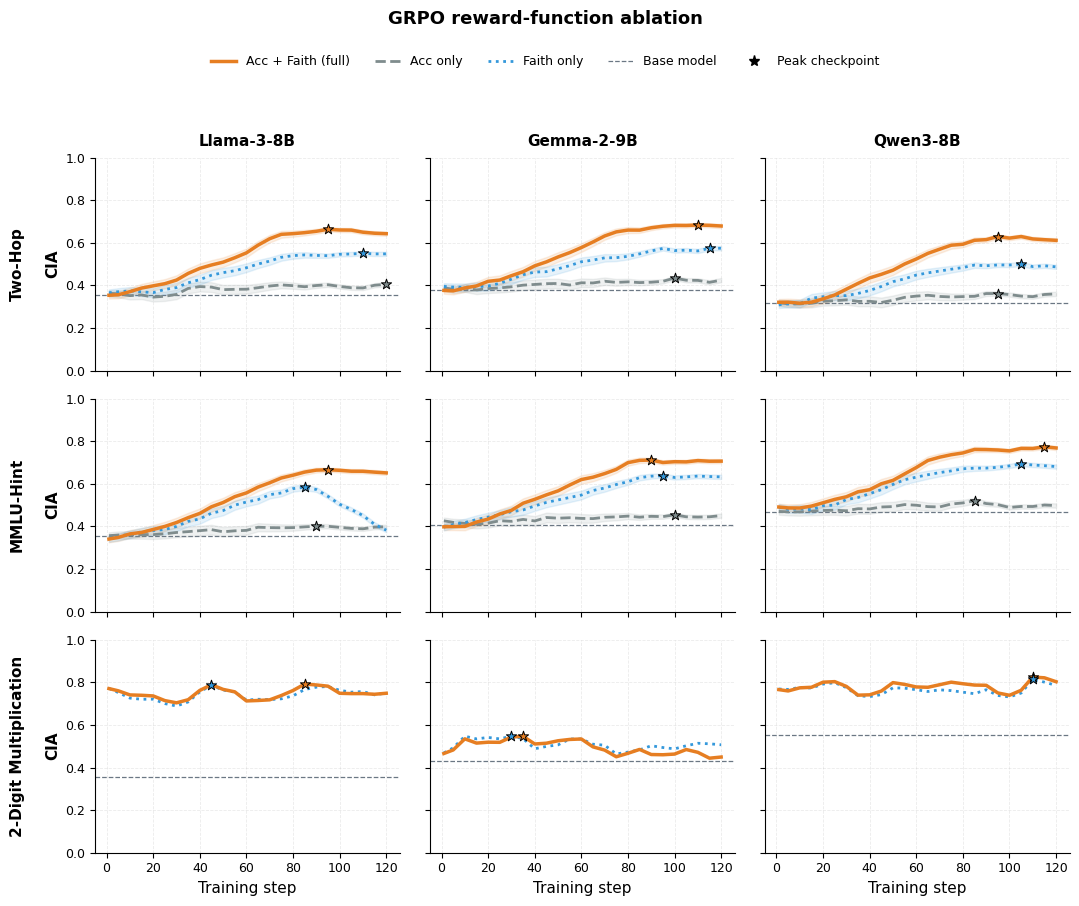

In [6]:
# ============================================================
# Main figure: 3 (tasks) × 3 (models) grid
# ============================================================

def draw_ablation_figure(show_acc_axis: bool = False,
                        figsize: tuple = (11.0, 8.5),
                        save_path: str | None = None):
    fig, axes = plt.subplots(len(TASKS), len(MODELS),
                             figsize=figsize, sharex=True, sharey=True)
    if len(TASKS) == 1: axes = np.array([axes])
    if len(MODELS) == 1: axes = axes[:, None]

    for i, task in enumerate(TASKS):
        for j, model in enumerate(MODELS):
            ax = axes[i, j]
            base = BASE_CIA.get((task, model))
            plot_panel(ax, task, model, base_cia=base,
                       show_acc_axis=show_acc_axis)
            # Column (model) labels on top row only.
            if i == 0:
                ax.set_title(MODEL_LABELS[model], pad=8, fontweight="bold")
            # Row (task) labels on left column only, annotated outside.
            if j == 0:
                ax.set_ylabel(f"{TASK_LABELS[task]}\n\nCIA", fontweight="bold")
            else:
                ax.set_ylabel("")
            # Bottom row keeps xlabel; top two hide it for compactness.
            if i != len(TASKS) - 1:
                ax.set_xlabel("")

    # Shared legend at top (outside grid).
    legend_handles = [
        Line2D([0], [0], color=cfg["color"], linestyle=cfg["ls"],
               linewidth=cfg["lw"], label=cfg["label"])
        for cfg in VARIANTS.values()
    ] + [
        Line2D([0], [0], color="#2C3E50", linestyle="--",
               linewidth=0.9, alpha=0.7, label="Base model"),
        Line2D([0], [0], color="black", marker="*", linestyle="None",
               markersize=8, markeredgecolor="black", label="Peak checkpoint"),
    ]
    fig.legend(handles=legend_handles, loc="upper center",
               ncol=len(legend_handles), frameon=False,
               bbox_to_anchor=(0.5, 1.02))

    fig.suptitle("GRPO reward-function ablation",
                 y=1.06, fontsize=13, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.97])

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        from pathlib import Path as _P
        png = str(_P(save_path).with_suffix(".png"))
        fig.savefig(png, dpi=250, bbox_inches="tight")
        print(f"Saved: {save_path}  +  {png}")
    return fig


fig = draw_ablation_figure(show_acc_axis=False,
                           save_path=str(FIG_OUT / "reward_ablation_cia.pdf"))
plt.show()

Saved: ${REPO_ROOT}/Figures/out/reward_ablation_cia_with_acc.pdf  +  ${REPO_ROOT}/Figures/out/reward_ablation_cia_with_acc.png


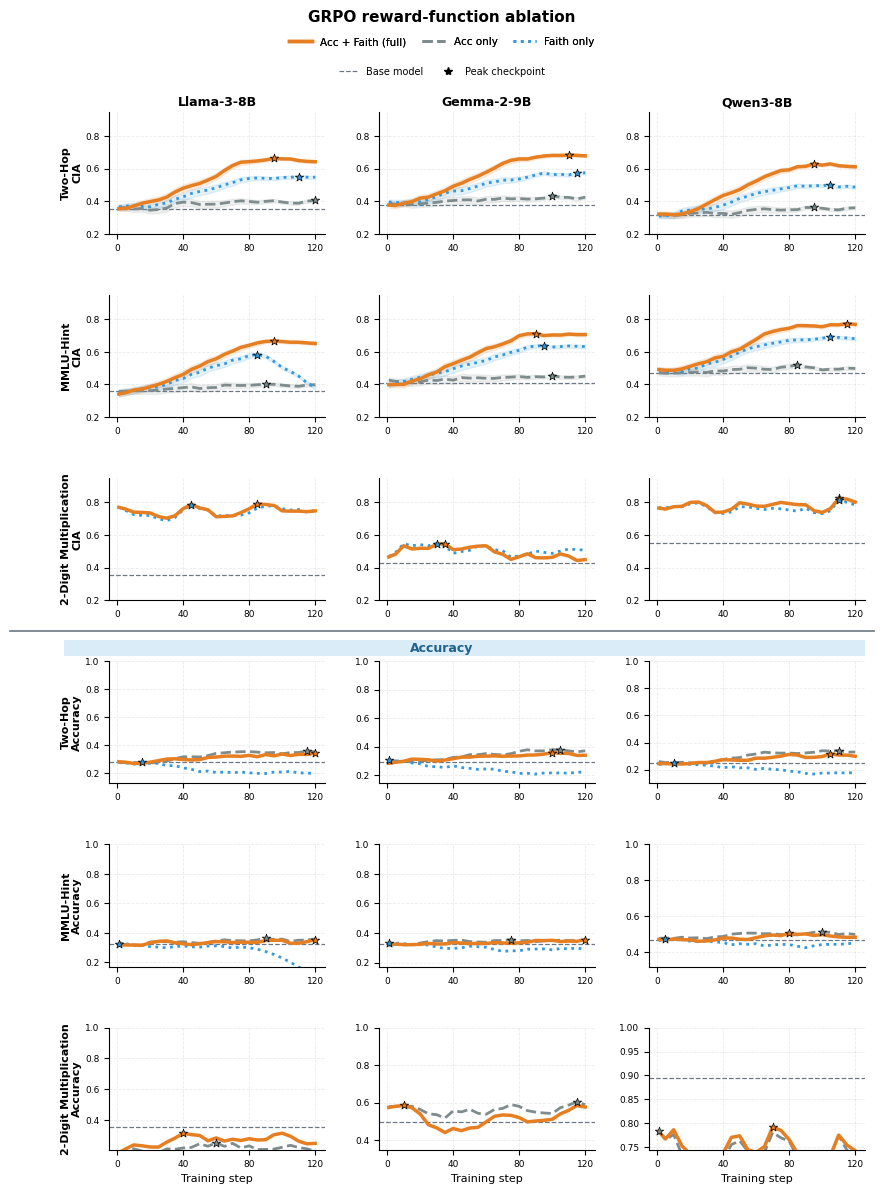

In [7]:
# ============================================================
# Variant: stacked CIA + Accuracy grids (6 rows × 3 cols)
# NeurIPS single-column: 5.5" wide × ~12" tall.
# ============================================================

BASE_ACC = {
    ("two_hop",        "llama3_8b"): 0.275,
    ("two_hop",        "gemma_9b"):  0.292,
    ("two_hop",        "qwen3_8b"):  0.249,
    ("hint",           "llama3_8b"): 0.321,
    ("hint",           "gemma_9b"):  0.323,
    ("hint",           "qwen3_8b"):  0.472,
    ("multiplication", "llama3_8b"): 0.355,
    ("multiplication", "gemma_9b"):  0.499,
    ("multiplication", "qwen3_8b"):  0.895,
}


def _plot_metric_panel(ax, task, model, metric: str,
                       base_hline: float | None = None,
                       smoothing_win: int = 3) -> int:
    """Render one subplot for one metric ('cia' or 'accuracy') across
    the three reward variants."""
    n_plotted = 0
    for vname, vcfg in VARIANTS.items():
        df = load_run(build_run_name(task, model, vname))
        if df is None or df.empty: continue
        if metric not in df.columns: continue

        xs = df["step"].values if "step" in df.columns else np.arange(len(df))
        ys = df[metric].values.astype(float)
        if np.all(np.isnan(ys)): continue
        if np.all(np.isnan(ys.astype(float))): continue
        ys_smooth = rolling(ys, smoothing_win)

        ax.plot(xs, ys_smooth, color=vcfg["color"], linestyle=vcfg["ls"],
                linewidth=vcfg["lw"], zorder=vcfg["z"], label=vcfg["label"])

        if metric == "cia" and "cia_std" in df.columns:
            ax.fill_between(xs, ys_smooth - df["cia_std"].values,
                                ys_smooth + df["cia_std"].values,
                                color=vcfg["color"], alpha=0.12, zorder=1)

        i_peak = int(np.nanargmax(ys_smooth))
        ax.scatter([xs[i_peak]], [ys_smooth[i_peak]],
                   color=vcfg["color"], s=40, marker="*",
                   edgecolor="black", linewidth=0.5, zorder=5)

        n_plotted += 1

    if base_hline is not None:
        ax.axhline(base_hline, color="#2C3E50", linestyle="--",
                   linewidth=0.9, alpha=0.7, zorder=0)
    if n_plotted == 0:
        ax.text(0.5, 0.5, "(no data)", transform=ax.transAxes,
                ha="center", va="center", color="#95A5A6", fontsize=9)
    return n_plotted


def _auto_ylim(task, model, metric, base_val):
    """Pick a y-range that shows the variation clearly instead of 0-1."""
    if metric == "cia":
        return (0.2, 0.95)
    # Accuracy: base_val - 0.15 to 1.0 (task/model specific lower bound).
    return (max(0.0, base_val - 0.15), 1.0)


def draw_ablation_stacked(figsize: tuple = (9., 12.0),
                          save_path: str | None = None):
    fig, axes = plt.subplots(2 * len(TASKS), len(MODELS),
                             figsize=figsize,
                             gridspec_kw={"hspace": 0.50, "wspace": 0.25})

    # ---- CIA block (top 3 rows) ----
    for i, task in enumerate(TASKS):
        for j, model in enumerate(MODELS):
            ax = axes[i, j]
            base = BASE_CIA.get((task, model))
            _plot_metric_panel(ax, task, model, metric="cia", base_hline=base)
            if i == 0:
                ax.set_title(MODEL_LABELS[model], pad=4,
                             fontweight="bold", fontsize=9)
            if j == 0:
                ax.set_ylabel(f"{TASK_LABELS[task]}\nCIA",
                              fontweight="bold", fontsize=8, labelpad=2)
            ax.set_xlabel("")
            ax.set_ylim(*_auto_ylim(task, model, "cia", base))
            ax.tick_params(axis="both", labelsize=6.5)
            ax.set_xticks([0, 40, 80, 120])

    # ---- Accuracy block (bottom 3 rows) ----
    for i, task in enumerate(TASKS):
        for j, model in enumerate(MODELS):
            ax = axes[len(TASKS) + i, j]
            base_acc = BASE_ACC.get((task, model))
            _plot_metric_panel(ax, task, model, metric="accuracy",
                               base_hline=base_acc)
            if j == 0:
                ax.set_ylabel(f"{TASK_LABELS[task]}\nAccuracy",
                              fontweight="bold", fontsize=8, labelpad=2)
            if i == len(TASKS) - 1:
                ax.set_xlabel("Training step", fontsize=8)
            else:
                ax.set_xlabel("")
            ax.set_ylim(*_auto_ylim(task, model, "accuracy", base_acc))
            ax.tick_params(axis="both", labelsize=6.5)
            ax.set_xticks([0, 40, 80, 120])

    fig.subplots_adjust(top=0.915, bottom=0.05, left=0.13, right=0.97)

    # Divider + banner separating the CIA block from the Accuracy block.
    fig.canvas.draw()
    cia_last  = axes[len(TASKS) - 1, 0].get_position()
    acc_first = axes[len(TASKS), 0].get_position()
    y_div = (cia_last.y0 + acc_first.y1) / 2
    line = plt.Line2D([0.02, 0.98], [y_div, y_div],
                      transform=fig.transFigure,
                      color="#2C3E50", linewidth=1.2, alpha=0.7)
    fig.add_artist(line)
    # Light-blue "Accuracy" banner right above the Accuracy block.
    y_acc = acc_first.y1 + 0.004
    fig.patches.append(plt.Rectangle(
        (0.08, y_acc), 0.89, 0.014,
        transform=fig.transFigure, facecolor="#3498DB", alpha=0.18,
        edgecolor="none", zorder=0))
    fig.text(0.5, y_acc + 0.007, "Accuracy",
             ha="center", va="center", fontsize=9,
             color="#1F618D", fontweight="bold",
             transform=fig.transFigure, zorder=10)

    # Shared legend at top (two rows).
    var_handles = [
        Line2D([0], [0], color=cfg["color"], linestyle=cfg["ls"],
               linewidth=cfg["lw"], label=cfg["label"])
        for cfg in VARIANTS.values()
    ]
    aux_handles = [
        Line2D([0], [0], color="#2C3E50", linestyle="--",
               linewidth=0.9, alpha=0.7, label="Base model"),
        Line2D([0], [0], color="black", marker="*", linestyle="None",
               markersize=6, markeredgecolor="black", label="Peak checkpoint"),
    ]
    leg1 = fig.legend(handles=var_handles, loc="upper center",
                      ncol=3, frameon=False,
                      bbox_to_anchor=(0.5, 0.985), fontsize=7.5,
                      columnspacing=1.5, handlelength=2.2)
    fig.add_artist(leg1)
    fig.legend(handles=aux_handles, loc="upper center",
               ncol=2, frameon=False,
               bbox_to_anchor=(0.5, 0.960), fontsize=7.0,
               columnspacing=1.5, handlelength=2.0)

    fig.suptitle("GRPO reward-function ablation",
                 y=1.000, fontsize=11, fontweight="bold")

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        from pathlib import Path as _P
        png = str(_P(save_path).with_suffix(".png"))
        fig.savefig(png, dpi=250, bbox_inches="tight")
        print(f"Saved: {save_path}  +  {png}")
    return fig


fig = draw_ablation_stacked(save_path=str(FIG_OUT / "reward_ablation_cia_with_acc.pdf"))
plt.show()


Saved: ${REPO_ROOT}/Figures/out/reward_ablation_final_bars.pdf  +  ${REPO_ROOT}/Figures/out/reward_ablation_final_bars.png


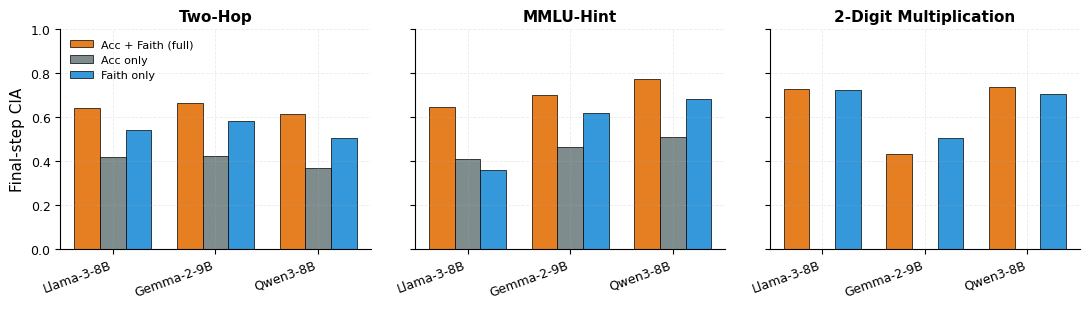

In [8]:
# ============================================================
# Companion: final-step summary bar chart
# ============================================================

def draw_final_bars(save_path: str | None = None):
    fig, axes = plt.subplots(1, len(TASKS), figsize=(11.0, 3.2), sharey=True)
    for i, task in enumerate(TASKS):
        ax = axes[i]
        x = np.arange(len(MODELS))
        width = 0.25
        for k, (vname, vcfg) in enumerate(VARIANTS.items()):
            vals = []
            for model in MODELS:
                df = load_run(build_run_name(task, model, vname))
                if df is None or df.empty or "cia" not in df.columns:
                    vals.append(np.nan)
                else:
                    vals.append(float(df["cia"].iloc[-1]))
            ax.bar(x + (k - 1) * width, vals, width,
                   label=vcfg["label"], color=vcfg["color"],
                   edgecolor="black", linewidth=0.5)
        ax.set_xticks(x); ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS],
                                              rotation=20, ha="right")
        ax.set_title(TASK_LABELS[task], fontweight="bold")
        if i == 0: ax.set_ylabel("Final-step CIA")
        ax.set_ylim(0, 1)
    axes[0].legend(loc="upper left", frameon=False, fontsize=8)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
        from pathlib import Path as _P
        png = str(_P(save_path).with_suffix(".png"))
        fig.savefig(png, dpi=250, bbox_inches="tight")
        print(f"Saved: {save_path}  +  {png}")
    return fig

fig = draw_final_bars(save_path=str(FIG_OUT / "reward_ablation_final_bars.pdf"))
plt.show()

## Expected data layout

Drop training exports under `Figures/runs/` named by `<task>__<model>__<variant>.csv`:

```
Figures/runs/
    two_hop__llama3_8b__acc_faith.csv
    two_hop__llama3_8b__acc_only.csv
    two_hop__llama3_8b__faith_only.csv
    two_hop__gemma_9b__acc_faith.csv
    ...
    multiplication__qwen3_8b__faith_only.csv
```

Required columns:
- `step` (int): training step index
- `cia`  (float, 0-1): CIA score at that step (evaluated on held-out set)

Optional columns (enables extras):
- `accuracy` — enables secondary-axis overlay when `show_acc_axis=True`
- `cia_std`  — enables shaded confidence band across seeds
- `kl`, `comp_len` — enables collapse-region highlighting (red shading
  where `kl > 2.0` or `comp_len < 100`)

Fallback: raw TRL `*.out` logs dropped as `<run_name>.out` will be parsed
with `rewards/*_accuracy_reward` + `rewards/*_parametric_faithfulness_reward`.
No CIA column → the faithfulness reward is used as the y-axis proxy
until you plug in real CIA-on-checkpoint evaluation.